# Reuters Assignment
## Adapted from Deep Learning with Python by Francois Chollet
#### Using the IMDB jupyter notebook as an example follow the prompts below to build a neural network to classify Reuters news wires into 46 different categories.

# Author: Nahian Arnob
# Student ID: 3038113

In [1]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))

In [2]:
# Add the necessary libraries and load the data.
from keras import backend
from keras.datasets import reuters
import numpy as np
import pandas as pd
import tensorflow as tf
(train_data, train_labels), (test_data, test_labels) = reuters.load_data(num_words = 10000)

2110848/2110848 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [3]:
import operator
# Print the word index
word_index = reuters.get_word_index()

# Print first few items to check
for i, (word, idx) in enumerate(word_index.items()):
    if i < 20:
        print(word, ":", idx)

550378/550378 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
mdbl : 10996
fawc : 16260
degussa : 12089
woods : 8803
hanging : 13796
localized : 20672
sation : 20673
chanthaburi : 20675
refunding : 10997
hermann : 8804
passsengers : 20676
stipulate : 20677
heublein : 8352
screaming : 20713
tcby : 16261
four : 185
grains : 1642
broiler : 20680
wooden : 12090
wednesday : 1220


In [4]:
# Here is the same function we created for vectorizing the IMDB data.
def vectorize_sequences(sequences, dimension=10000):
    rword_matrix = tf.sparse.SparseTensor(
        # The non-zero locations in each row correspond to the word indices that are found in the document
        indices=[[row_idx, word_idx] for row_idx, word_indices in enumerate(sequences) for word_idx in set(word_indices)],
        # Use "1" as the value of each non-zero index (indicating the word is used in the document)
        values=[1 for row_idx, word_indices in enumerate(sequences) for word_idx in set(word_indices)],
        # The overall tensor shape
        dense_shape=[len(sequences), dimension]
    )
    # Optimize by ordering the non-zero indices in ascending row-major order
    word_matrix = tf.sparse.reorder(word_matrix)
    return word_matrix

In [9]:
NUM_WORDS = 10000

In [6]:
# Split the training data into an 80/20 train/validation split, and then vectorize the train/test/validation datasets
from sklearn.model_selection import train_test_split

train_data, valid_data, train_labels, valid_labels = train_test_split( train_data, train_labels, test_size=0.2, random_state=42, stratify=train_labels, shuffle= True)

In [10]:
def vectorize_sequences(sequences, dimension=NUM_WORDS):
    # use a set() per doc so repeated word indices only count once (multi-hot)
    idx = [[row, word] for row, words in enumerate(sequences) for word in set(words) if word < dimension]
    vals = [1] * len(idx)
    x = tf.sparse.SparseTensor(indices=idx, values=vals, dense_shape=[len(sequences), dimension])
    return tf.sparse.reorder(x)

In [11]:
# Vectorize train/valid/test
x_train = vectorize_sequences(train_data, NUM_WORDS)
x_valid = vectorize_sequences(valid_data, NUM_WORDS)
x_test  = vectorize_sequences(test_data,  NUM_WORDS)

In [12]:
# Labels to numpy arrays (keep as ints for now; we’ll one-hot later for 46 classes)
y_train = np.asarray(train_labels, dtype="int32")
y_valid = np.asarray(valid_labels, dtype="int32")
y_test  = np.asarray(test_labels,  dtype="int32")

In [13]:
# Print the unique train labels (there should be 46)
unique_labels = np.unique(y_train)
print("Unique train labels:", unique_labels)
print("Number of unique classes:", len(unique_labels))

# Print the shape of x_train
print("Shape of x_train:", x_train.shape)



Unique train labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45]
Number of unique classes: 46
Shape of x_train: (7185, 10000)


In [15]:
# Keras has a built-in function for categorical encoding which we saw in the MNIST workbook
from tensorflow.keras.utils import to_categorical

In [16]:
# Convert the labels to categorical
y_train_oh = to_categorical(y_train, num_classes=46)
y_valid_oh = to_categorical(y_valid, num_classes=46)
y_test_oh  = to_categorical(y_test,  num_classes=46)

print("y_train shape (one-hot):", y_train_oh.shape)
print("y_valid shape (one-hot):", y_valid_oh.shape)
print("y_test shape (one-hot):", y_test_oh.shape)

print("First label (int):", y_train[0])
print("First label (one-hot):", y_train_oh[0])

y_train shape (one-hot): (7185, 46)
y_valid shape (one-hot): (1797, 46)
y_test shape (one-hot): (2246, 46)
First label (int): 3
First label (one-hot): [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [17]:
# Import models and layers from Keras
from keras import models
from keras import layers

In [20]:
# Build a sequential model network with 1 hidden layer. The input and hidden layer must have more hidden units
# than the number of classification categories. Things to think about: input and hidden layer activation,
# output activation for a multiclass problem, input shape, output units

from tensorflow import keras

NUM_CLASSES  = 46

# SparseTensor make it dense for Dense layers:
def ensure_dense(x):
    return tf.sparse.to_dense(x) if isinstance(x, tf.SparseTensor) else x

x_train_d = ensure_dense(x_train)
x_valid_d = ensure_dense(x_valid)
x_test_d  = ensure_dense(x_test)

# Model: 1 hidden layer
model = keras.Sequential([
    layers.Input(shape=(NUM_WORDS,)),          # input shape matches vectorized features
    layers.Dense(128, activation="relu"),      # hidden units > 46
    layers.Dropout(0.3),                       # (optional) light regularization
    layers.Dense(NUM_CLASSES, activation="softmax")  # multiclass output
])


model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 128)            │     1,280,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 46)             │         5,934 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,286,062 (4.91 MB)

 Trainable params: 1,286,062 (4.91 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# Compile the model. Think about what optimizer, loss function, and metrics will you use.

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",           # use one-hot labels: y_train_oh / y_valid_oh / y_test_oh
    metrics=["accuracy"]
)

In [22]:
# Train your model on the training data for 20 epochs and 500 batch size and a validation split = 20%.

history = model.fit(
    x_train_d, y_train_oh,
    epochs=20,
    batch_size=500,
    validation_split=0.2,
    verbose=1
)


Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 110ms/step - accuracy: 0.3313 - loss: 3.4581 - val_accuracy: 0.6013 - val_loss: 2.4177
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.6280 - loss: 2.1245 - val_accuracy: 0.6548 - val_loss: 1.7099
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - accuracy: 0.7042 - loss: 1.4166 - val_accuracy: 0.7126 - val_loss: 1.3945
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - accuracy: 0.7724 - loss: 1.0445 - val_accuracy: 0.7502 - val_loss: 1.2296
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - accuracy: 0.8343 - loss: 0.7889 - val_accuracy: 0.7697 - val_loss: 1.1307
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - accuracy: 0.8741 - loss: 0.6589 - val_accuracy: 0.7801 - val_loss: 1.0648
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - accuracy: 0.8988 - loss: 0.5316 - val_accuracy: 0.7891 - val_loss: 1.0164
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 130ms/step - accuracy: 0.9154 - loss: 0.4605 - val_accuracy: 0.7905 -

In [23]:
import matplotlib.pyplot as plt

In [24]:
# Use this bit of code to view the History output.
hist = pd.DataFrame(history.history)
print(hist.tail())

    accuracy      loss  val_accuracy  val_loss
15  0.964857  0.155957      0.803758  0.917523
16  0.965553  0.147512      0.800278  0.923817
17  0.969207  0.134775      0.803062  0.930371
18  0.966945  0.126634      0.803758  0.931087
19  0.967815  0.121823      0.805150  0.935054


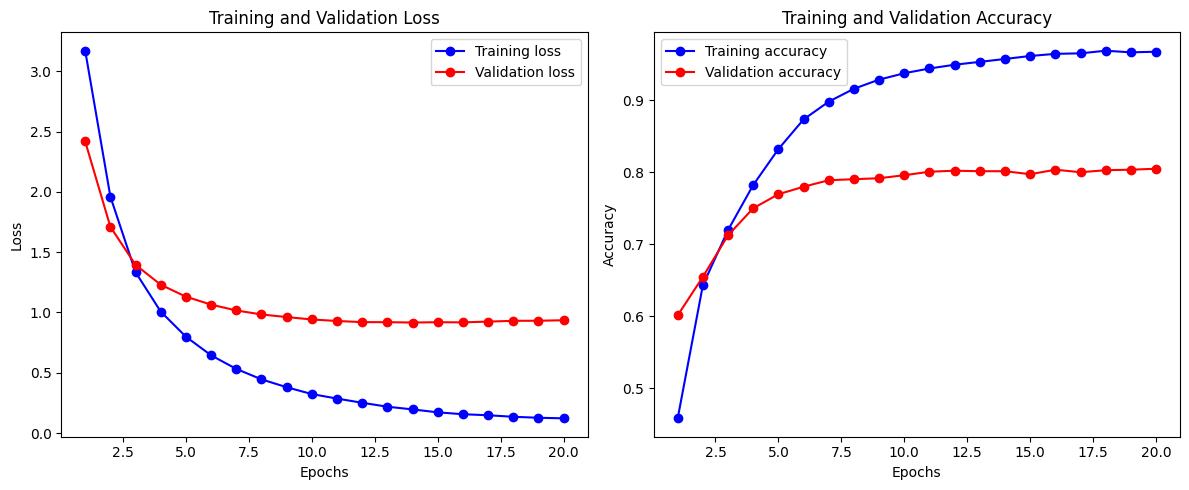

In [25]:
# Let's plot the loss and accuracy vs epochs

# Extract training history
hist = history.history
epochs = range(1, len(hist["loss"]) + 1)

# --- Plot Loss ---
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, hist["loss"], "bo-", label="Training loss")
plt.plot(epochs, hist["val_loss"], "ro-", label="Validation loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

# --- Plot Accuracy ---
plt.subplot(1, 2, 2)
plt.plot(epochs, hist["accuracy"], "bo-", label="Training accuracy")
plt.plot(epochs, hist["val_accuracy"], "ro-", label="Validation accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


The training loss decreases consistently, but the validation loss stabilizes around epoch 8–10, suggesting that the model starts overfitting beyond this point. Similarly, training accuracy continues to increase while validation accuracy plateaus near 80%. This indicates that the model has learned the general patterns in the Reuters dataset, but training for more than ~8 epochs does not improve generalization.

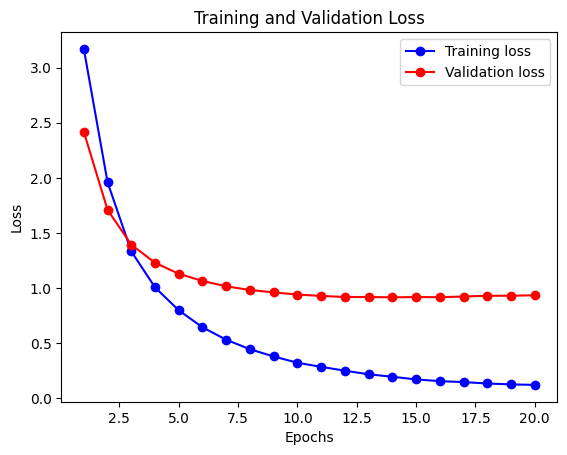

In [26]:
# Use the IMDB example to plot the validataion and training loss vs epochs
hist = history.history
epochs = range(1, len(hist["loss"]) + 1)

plt.plot(epochs, hist["loss"], "bo-", label="Training loss")       # blue dots & line
plt.plot(epochs, hist["val_loss"], "ro-", label="Validation loss") # red dots & line
plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

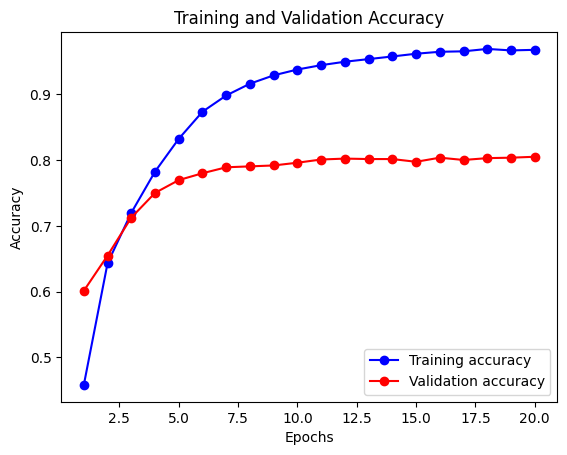

In [27]:
# Use the IMDB example to plot the validation and training accuracy vs epochs

hist = history.history
epochs = range(1, len(hist["accuracy"]) + 1)

plt.plot(epochs, hist["accuracy"], "bo-", label="Training accuracy")       # blue dots & line
plt.plot(epochs, hist["val_accuracy"], "ro-", label="Validation accuracy") # red dots & line
plt.title("Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [28]:
# Evaluate the model on the test data and print the results
test_loss, test_acc = model.evaluate(x_test_d, y_test_oh, verbose=1)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8017 - loss: 0.9762
Test Loss: 1.0021023750305176
Test Accuracy: 0.7938557267189026


The evaluation results indicate that the Reuters classification model performs well on unseen data, achieving a test accuracy of about 79% and a test loss close to 1.0. This means the model is able to correctly classify roughly four out of five newswires into the correct category among the 46 possible classes. While the training accuracy was much higher (around 98%), the lower test accuracy highlights some overfitting, which is common when working with high-dimensional text data. Overall, the model has successfully learned meaningful patterns from the dataset.

Build a new model and try to get the  accuracy as high as you can. Things to try: more hidden layers and hiddent units, activation types, epochs, batch size, and validation_split. Try as many models as you like.  

Be sure to clear the session each time: `backend.clear_session()`. Copy your best model the end of the notebook.
